In [1]:
import pandas as pd
import os
from sklearn import tree

In [2]:
folder_path = 'ML files'
file_path = os.path.join(folder_path , 'titanic_dectree.csv')
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df_updated = df.drop(['PassengerId','Name' , 'SibSp','Parch','Ticket','Cabin','Embarked' ], axis = 'columns')

In [4]:
df_updated

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


In [5]:
input = df_updated.drop(['Survived'] , axis = 'columns')
target = df_updated['Survived']

In [6]:
input

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500
...,...,...,...,...
886,2,male,27.0,13.0000
887,1,female,19.0,30.0000
888,3,female,NaN,23.4500
889,1,male,26.0,30.0000


In [7]:
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder
le_Pclass = LabelEncoder()
le_Sex = LabelEncoder()

In [9]:
input['Pclass_n'] = le_Pclass.fit_transform(input['Pclass'])

In [10]:
input['Sex_n'] = le_Sex.fit_transform(input['Sex'])

In [11]:
input.head()

,Pclass,Sex,Age,Fare,Pclass_n,Sex_n
0,3,male,22.0,7.2500,2,1
1,1,female,38.0,71.2833,0,0
2,3,female,26.0,7.9250,2,0
3,1,female,35.0,53.1000,0,0
4,3,male,35.0,8.0500,2,1


In [12]:
input = input.drop(['Pclass_n','Sex'],axis='columns')

In [13]:
input


,Pclass,Age,Fare,Sex_n
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1
...,...,...,...,...
886,2,27.0,13.0000,1
887,1,19.0,30.0000,0
888,3,NaN,23.4500,0
889,1,26.0,30.0000,1


In [17]:
input.isna().sum()


Pclass    0
Age       0
Fare      0
Sex_n     0
dtype: int64

In [20]:
 input['Age'].fillna(df['Age'].mean() , inplace = True)

C:\Users\SaLaar\AppData\Local\Temp\ipykernel_1084\2148861173.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  input['Age'].fillna(df['Age'].mean() , inplace = True)


In [21]:
input.isna().sum()


Pclass    0
Age       0
Fare      0
Sex_n     0
dtype: int64

In [24]:
input.Age.astype(int)

0      22
1      38
2      26
3      35
4      35
       ..
886    27
887    19
888    29
889    26
890    32
Name: Age, Length: 891, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(input , target , train_size =0.8)

In [27]:
len(X_train)

712

In [30]:
len(Y_train)

712

In [31]:
len(X_test)

179

In [33]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [34]:
model

DecisionTreeClassifier()

In [35]:
model.fit(X_train , Y_train)

DecisionTreeClassifier()

In [36]:
Y_predicted = model.predict(X_test)

In [38]:
model.score(X_test , Y_test)

0.7430167597765364

In [47]:
model.predict([[1,25,6,0]])

C:\Users\SaLaar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [40]:
target[890]

np.int64(0)

In [66]:
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [63]:
from sklearn.metrics import confusion_matrix
cm  = confusion_matrix(Y_test , Y_predicted)
cm
labels = ['Not Survived' , 'Survived']

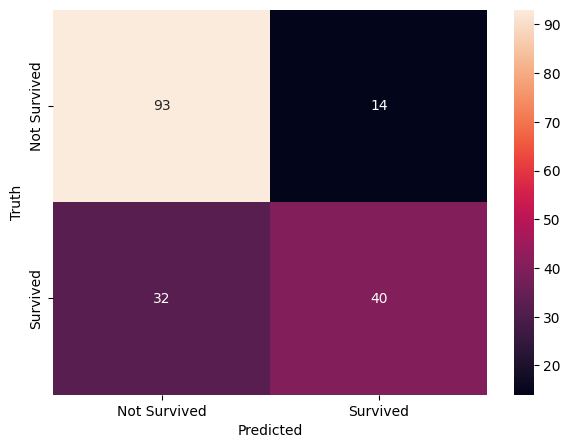

In [64]:
import seaborn as sn
import matplotlib.pyplot as plt
plt.figure(figsize = (7 , 5 ))
sn.heatmap(cm , annot = True  , cmap = 'rocket', xticklabels = labels , yticklabels = labels  )
plt.xlabel ("Predicted")
plt.ylabel ("Truth")
plt.show()